In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class MesoNet4(nn.Module):
    def __init__(self):
        super(MesoNet4, self).__init__()
        self.features = nn.Sequential(
            
            nn.Conv2d(3, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   
            
            nn.Conv2d(8, 8, 5, padding=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   
           
            nn.Conv2d(8, 16, 5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   
            
            nn.Conv2d(16, 16, 5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),   
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, 16),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, csv_path, split, transform=None):
        df = pd.read_csv(csv_path)
        self.data = df[df['split'] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']   
        label = row['label']          
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

In [4]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    for images, labels in tqdm(dataloader, desc='Training'):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    auc = roc_auc_score(all_labels, all_preds)
    return epoch_loss, auc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(outputs.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    auc = roc_auc_score(all_labels, all_preds)
    return epoch_loss, auc

In [ ]:

DATA_CSV = r"D:\coding files\master_faces.csv"  
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-3


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


train_dataset = DeepfakeDataset(DATA_CSV, 'train', transform=train_transform)
val_dataset = DeepfakeDataset(DATA_CSV, 'val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 64519
Validation samples: 12508


In [ ]:
model = MesoNet4().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_auc = 0.0
train_losses, val_losses = [], []
train_aucs, val_aucs = [], []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    train_loss, train_auc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_aucs.append(train_auc)
    val_aucs.append(val_auc)

    print(f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val AUC:   {val_auc:.4f}")

    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), 'mesonet4_best.pth')
        print(f"*** New best model saved (AUC = {val_auc:.4f}) ***")

# Save final model too
torch.save(model.state_dict(), 'mesonet4_final.pth')
print("\nTraining complete!")


Epoch 1/20


Evaluating: 100%|██████████| 391/391 [01:08<00:00,  5.72it/s]


Train Loss: 0.0799, Train AUC: 0.9958
Val Loss:   0.0581, Val AUC:   0.9978
*** New best model saved (AUC = 0.9978) ***

Epoch 2/20


Evaluating: 100%|██████████| 391/391 [00:43<00:00,  8.90it/s]


Train Loss: 0.0387, Train AUC: 0.9989
Val Loss:   0.0656, Val AUC:   0.9980
*** New best model saved (AUC = 0.9980) ***

Epoch 3/20


...

Train Loss: 0.0106, Train AUC: 0.9999
Val Loss:   0.0473, Val AUC:   0.9990

Epoch 19/20


Evaluating: 100%|██████████| 391/391 [00:42<00:00,  9.22it/s]


Train Loss: 0.0103, Train AUC: 0.9999
Val Loss:   0.0552, Val AUC:   0.9991

Epoch 20/20


Evaluating: 100%|██████████| 391/391 [00:42<00:00,  9.18it/s]

Train Loss: 0.0094, Train AUC: 0.9999
Val Loss:   0.0477, Val AUC:   0.9990

Training complete!


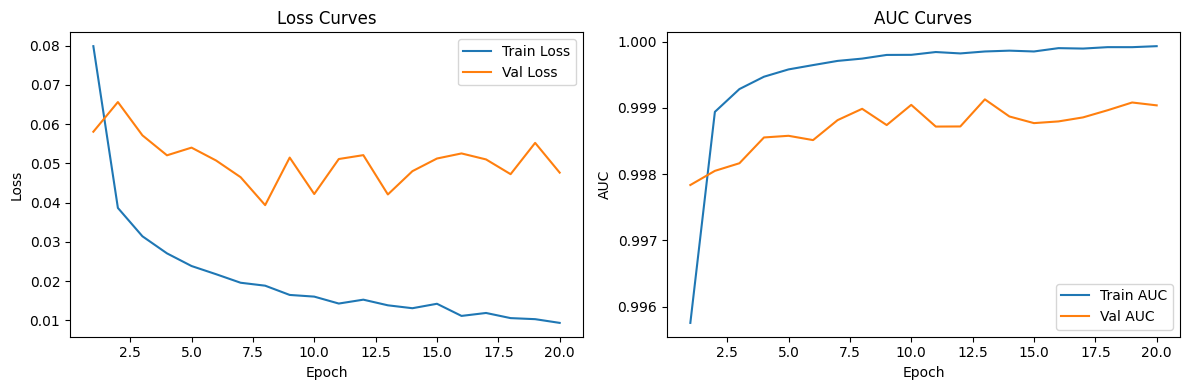

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_aucs)+1), train_aucs, label='Train AUC')
plt.plot(range(1, len(val_aucs)+1), val_aucs, label='Val AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.title('AUC Curves')

plt.tight_layout()
plt.savefig('mesonet_training_curves.png')  
plt.show()

In [ ]:

class TestDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        df = pd.read_csv(csv_path)
        self.data = df[df['split'] == 'test'].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']   
        label = row['label']
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label, img_path


model = MesoNet4().to(device)
model.load_state_dict(torch.load('mesonet4_best.pth', map_location=device))
model.eval()


test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


test_dataset = TestDataset(DATA_CSV, transform=test_transform)  # DATA_CSV pehle define hai na? Agar nahi toh yahan r"D:\coding files\master_faces.csv" daal de
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)


results = []
all_labels = []
all_scores = []

with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(device)
        outputs = model(images).squeeze().cpu().numpy()
        if outputs.ndim == 0:
            outputs = [outputs]
        for p, lbl, sc in zip(paths, labels.tolist(), outputs.tolist()):
            results.append({'image_path': p, 'true_label': lbl, 'fake_score': sc})
            all_labels.append(lbl)
            all_scores.append(sc)


df_pred = pd.DataFrame(results)
df_pred.to_csv('mesonet_predictions.csv', index=False)


test_auc = roc_auc_score(all_labels, all_scores)
print(f"Test AUC: {test_auc:.4f}")
print("Predictions saved to 'mesonet_predictions.csv'")

Test AUC: 0.9972
Predictions saved to 'mesonet_predictions.csv'


In [1]:
%%writefile mesonet4_model.py
import torch
import torch.nn as nn

class MesoNet4(nn.Module):
    def __init__(self):
        super(MesoNet4, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 8, 5, padding=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, 5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 16, 5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 8 * 8, 16),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.5),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Writing mesonet4_model.py
